In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd

# Define the input Excel file path and the output CSV file path
excel_file_path = '/content/attendance.csv.xlsx'
csv_file_path = '/content/attendance.csv'

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(excel_file_path)

# Save the DataFrame to a CSV file
df.to_csv(csv_file_path, index=False)

print(f"Successfully converted '{excel_file_path}' to '{csv_file_path}'")

Successfully converted '/content/attendance.csv.xlsx' to '/content/attendance.csv'


The file `/content/attendance.csv.xlsx` has been converted to `/content/attendance.csv`.

In [11]:
df['Attendance_Percentage'] = (df['classes attended'] / df['total classes']) * 100
df.head()

,student id,total classes,classes attended,study hours,assignments submitted,Attendance_Percentage
0,1,100,90,4,8,90.0
1,2,100,45,3,3,45.0
2,3,100,80,1,7,80.0
3,4,100,30,2,2,30.0
4,5,100,70,3,1,70.0


In [12]:
def label_attendance(x):
    if x >= 75:
        return "Regular"
    else:
        return "Irregular"

df['Behavior'] = df['Attendance_Percentage'].apply(label_attendance)
df.head()

,student id,total classes,classes attended,study hours,assignments submitted,Attendance_Percentage,Behavior
0,1,100,90,4,8,90.0,Regular
1,2,100,45,3,3,45.0,Irregular
2,3,100,80,1,7,80.0,Regular
3,4,100,30,2,2,30.0,Irregular
4,5,100,70,3,1,70.0,Irregular


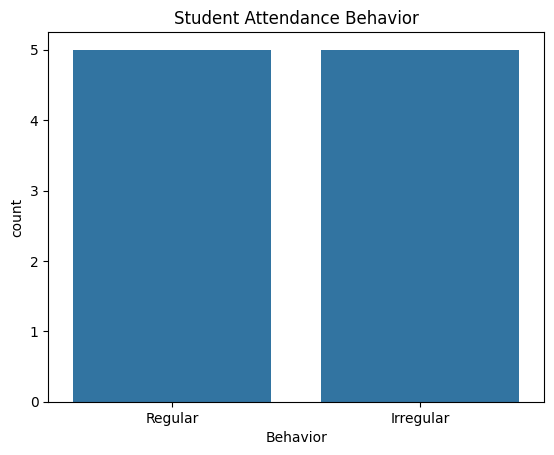

In [13]:
sns.countplot(x='Behavior', data=df)
plt.title("Student Attendance Behavior")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df[['Attendance_Percentage']]
y = df['Behavior']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.5


In [18]:
new_attendance = [[80]]
result = model.predict(new_attendance)
print("Student Behavior:", result)

Student Behavior: ['Regular']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
